---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.6 (Linear Regression using Scikit-Learn Library)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook

1. Scikit-Learn WorkFlow (Supervised ML)<br>
    I. Data Acquisition<br>
    II. Data Pre-Processing and Feature Engineering<br>
    III. Choose an Appropriate Supervised Machine Learning Model<br>
    IV. Train-Test-Split<br>
    V. Create an Instance of Machine Learning Model/Estimator using Scikit-Learn<br>
    VI. Train the Model<br>
    VII. Carry out Prediction<br>
    VIII. Evaluate the Model<br>
    IX. Improve via Hyper-Parameter Tuning<br>
    X. Model Deployment<br>

# 1. Scikit-Learn WorkFlow (Supervised ML)

<img align="center" width="1000" src="images/sklearn-workflow1.png"  >

<img align="right" width="500" src="images/acquire-data.png"  >

# I. Data Acquisition
- **Use Libraries Built-in Datasets:**
    - Seaborn: (iris, titanic, tips, flights, panguins, car_crashes)
    - Scikit-learn: (iris, digits, diabetes, Bostan housing) 
    - NLTK: (movie-reviews, product_reviews, twitter_samples, gutenerg, genesis, timeit, voice, wordnet, sentiword)
    
- **Use Public Dataset Repositories:**
    - https://www.kaggle.com/
    - https://data.gov/
    - https://archive.ics.uci.edu/ml/index.php
    - https://github.com/
- **Use Company's Database:** (SQL, NOSQL, Data warehouse, Data lake)
- **Generate your own Datasets:**
    - Use Web scraping or Web API </li>
    - IoT Devices </li>
    - Crowd Sourcing (Amazon Mechanical Turk, Lionbridge AI)
    - Data Augmentation

**Techniques to Label your Datasets:**
<h3 align="center"><div class="alert alert-success" style="margin: 20px">Better data often beats better algorithms</h3>

### A Sample Advertising Dataset

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv("datasets/advertising4D.csv")
df

/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


>- How strong is the relationship between input features and output sales?
>- Which ad types contribute more to sales?
>- What is the effect of each ad type on sales?
>- Given an advertising budget, can we predict future sales?

## II. Data Pre-Processing and Feature Engineering
- `Data Preprocessing` involves actions that we need to perform on the dataset in order to make it ready to be fed to the machine learning model.
- `Feature Engineering` is the process of using domain knowledge to extract features from raw data via data mining techniques.<br><br>

<img align="center" width="800" src="images/housing-dataset3.png"  >
<br><br>

- Pre-processing package of sklearn provides a bundle of utility functions and transformer classes for data preprocessing (will cover later).
    - **Detecting and handling outliers** 
        - Univariate (Z-Score, IQR, Percentiles)
        - Multivariate Analysis (Depth-based, Distance-based, Density-based methods)
        - Trimming, Capping/Winsorization, Discritization
    - **Missing values Imputation** 
        - Univariate Imputation (Panda's `fillna()` method, Sklearn's `SimpleImputer()` transformer)
        - Multivariate Imputation (Sklearn's `IterativeImputer()` and  `KNNImputer()` transformers)
    - **Encoding Categorical Features**
        - Encode Nominal i/p features using Pandas `get_dummies()` and Scikit-Learn's `OneHotEncoder()`  
        - Encode Ordinal i/p features using Scikit-Learn's `OrdinalEncoder()`
        - Encode categorical o/p column(s) using Scikit-Learn's `LabelEncoder()`
    - **Feature Scaling**
        - Use numPy to perform maxabs, minmax, standard and robust scaling
        - Use Sklearn's `MaxAbsScalar` , `MinMaxScalar`, `StandardScalar`, `RobustScalar` transformers
    - **Extracting Information** 
        - Use Sklearn's `CountVectorizer`, `DictVectorizer` , `TfidfVectorizer`, and `TfidfTransformer`
    - **Combining Information**
        - Use `FeatureUnion`, `Pipeline`, `PCA`

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


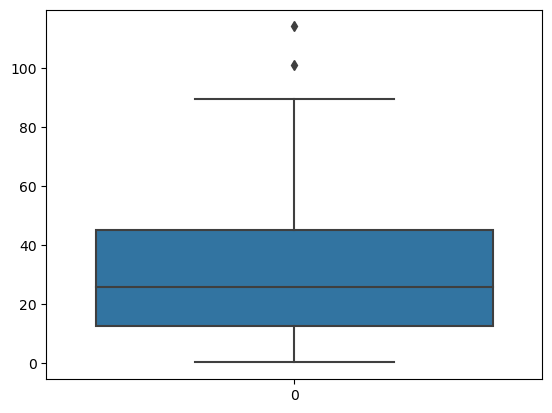

In [3]:
sns.boxplot(data=df['newspaper']);

## III. Choose an Appropriate Machine Learning Model (Estimator)
- There are many models that researchers and datascientists have created over the years. 
- Some are very well suited for numerical data, some are good for textual data, while some are good for image data.
<h3 align="center"><div class="alert alert-success" style="margin: 20px">The right model for your data depends on the type of the data you have and what you want to do with it</h3>
- This flowchart is designed to give users a rough guide to choose an estimator to try on your data.
<img align="center" width="750"  src="images/model-selection.png"  > 

# Assumptions for Linear Regression
<font face = "Garamond" color=green size=4>**a. Linearity** </font>


<font face = "Garamond" color=green size=4>**b. Independence** </font>


<font face = "Garamond" color=green size=4>**c. Homoscedasticity**</font>
    
    
<font face = "Garamond" color=green size=4>**d. Normality** </font>

<font face = "Garamond" color=green size=5>**a. Linearity:**
- <font face = "Garamond" color=red size=4>What do you mean by this assumption?</font><br>
    - All the feature variables should be somehow correlated with the output variable. 
- <font face = "Garamond" color=red size=4>How to determine if this assumption is met?</font><br>
    - Can be checked using scatterplot and Pearson Correlation Coefficient among the feature/independent and the output/dependent variables.
- <font face = "Garamond" color=red size=4>Problem Caused?</font><br>
    - Voilation of this assumption will cause overfitting.
- <font face = "Garamond" color=red size=4>What to do if this assumption is violated?</font><br>
    - Add ploynomial features (i.e., add quadratic terms and interaction terms).
    - Apply a nonlinear transformation to the independent and/or dependent variable. For example, take the log/squareroot/reciprocal of the independent and/or dependent variable.

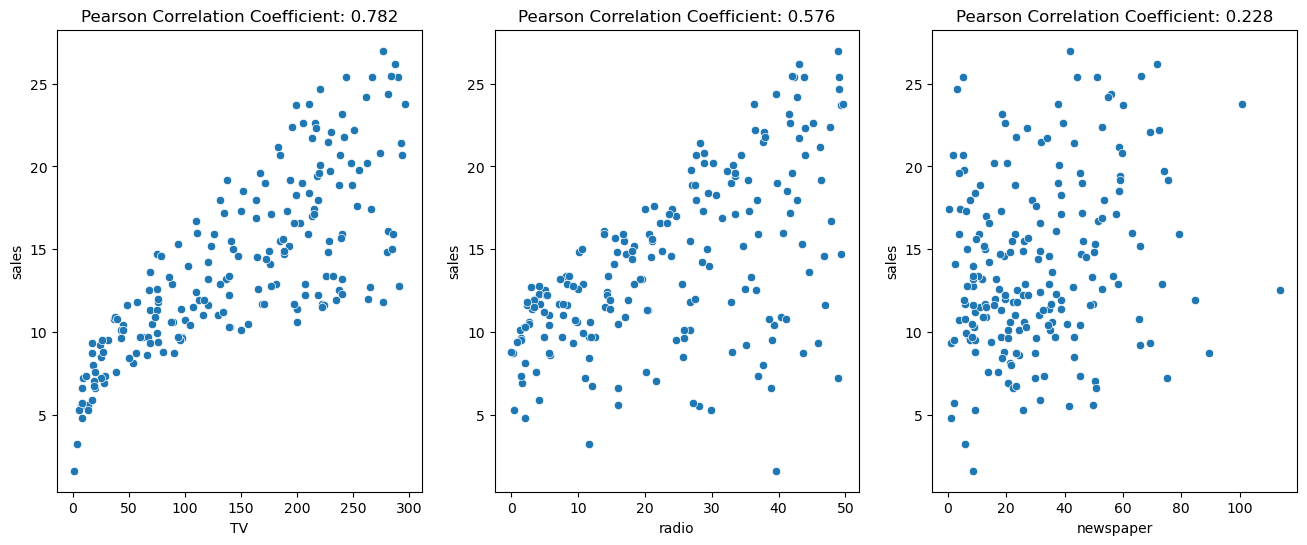

In [4]:
%matplotlib inline
tv = np.array(df['TV'])
radio = np.array(df['radio'])
newspaper = np.array(df['newspaper'])

x=tv
y = np.array(df['sales'])
numerator = sum(np.multiply(x - np.mean(x), y - np.mean(y)))
denominator = np.multiply((np.sqrt(np.sum((x-np.mean(x))**2))), np.sqrt(np.sum((y-np.mean(y))**2)))
corr_coef_tv = numerator / denominator

x=radio
y = np.array(df['sales'])
numerator = sum(np.multiply(x - np.mean(x), y - np.mean(y)))
denominator = np.multiply((np.sqrt(np.sum((x-np.mean(x))**2))), np.sqrt(np.sum((y-np.mean(y))**2)))
corr_coef_radio = numerator / denominator

x=newspaper
y = np.array(df['sales'])
numerator = sum(np.multiply(x - np.mean(x), y - np.mean(y)))
denominator = np.multiply((np.sqrt(np.sum((x-np.mean(x))**2))), np.sqrt(np.sum((y-np.mean(y))**2)))
corr_coef_newspaper = numerator / denominator


fig, (ax1,ax2, ax3) = plt.subplots(1,3, figsize=(16,6))
ax1.set_title("Pearson Correlation Coefficient: {:.3f}".format(corr_coef_tv))
sns.scatterplot(x='TV', y='sales', data=df, ax=ax1)
ax2.set_title("Pearson Correlation Coefficient: {:.3f}".format(corr_coef_radio))
sns.scatterplot(x='radio', y='sales', data=df, ax=ax2)
ax3.set_title("Pearson Correlation Coefficient: {:.3f}".format(corr_coef_newspaper))
sns.scatterplot(x='newspaper', y='sales', data=df, ax=ax3);

<font face = "Garamond" color=green size=5>**b. Independence:**
- <font face = "Garamond" color=red size=4>What do you mean by this assumption?</font><br>
    - All the feature variables should NOT have any correlation with eachother (should be independent). 
- <font face = "Garamond" color=red size=4>How to determine if this assumption is met?</font><br>
    - Can be checked using scatterplot and Pearson Correlation Coefficient among the feature/independent variables.
- <font face = "Garamond" color=red size=4>Problem Caused?</font><br>
    - Violation of this assumption will cause multicollinearity, due to which regression coefficients will become unstable and difficult to interpret
- <font face = "Garamond" color=red size=4>What to do if this assumption is violated?</font><br>
    - For positive serial correlation, consider adding lags of the dependent and/or independent variable to the model.
    - For negative serial correlation, check to make sure that none of your variables are overdifferenced.
    - For seasonal correlation, consider adding seasonal dummy variables to the model.
    
>- A time series data is the data that is observed sequentially over time. Read at your own about ARIMA (Auto Regressive Integrated Moving Average) and Seasonal ARIMA which is a statistical model used for forecasting time series data.

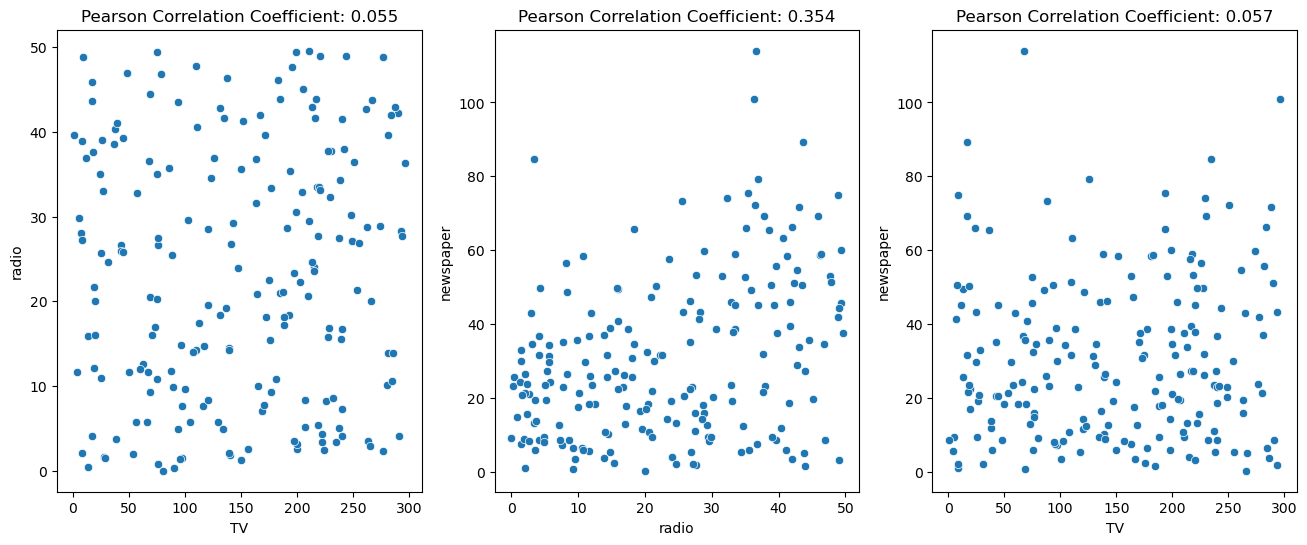

In [5]:
tv = np.array(df['TV'])
radio = np.array(df['radio'])
newspaper = np.array(df['newspaper'])

x=tv
y = radio
numerator = sum(np.multiply(x - np.mean(x), y - np.mean(y)))
denominator = np.multiply((np.sqrt(np.sum((x-np.mean(x))**2))), np.sqrt(np.sum((y-np.mean(y))**2)))
corr_coef_tv_radio = numerator / denominator

x=radio
y = newspaper
numerator = sum(np.multiply(x - np.mean(x), y - np.mean(y)))
denominator = np.multiply((np.sqrt(np.sum((x-np.mean(x))**2))), np.sqrt(np.sum((y-np.mean(y))**2)))
corr_coef_radio_newspaper = numerator / denominator

x=tv
y = newspaper
numerator = sum(np.multiply(x - np.mean(x), y - np.mean(y)))
denominator = np.multiply((np.sqrt(np.sum((x-np.mean(x))**2))), np.sqrt(np.sum((y-np.mean(y))**2)))
corr_coef_tv_newspaper = numerator / denominator



fig, (ax1,ax2, ax3) = plt.subplots(1,3, figsize=(16,6))
ax1.set_title("Pearson Correlation Coefficient: {:.3f}".format(corr_coef_tv_radio))
sns.scatterplot(x='TV', y='radio', data=df, ax=ax1)
ax2.set_title("Pearson Correlation Coefficient: {:.3f}".format(corr_coef_radio_newspaper))
sns.scatterplot(x='radio', y='newspaper', data=df, ax=ax2)
ax3.set_title("Pearson Correlation Coefficient: {:.3f}".format(corr_coef_tv_newspaper))
sns.scatterplot(x='TV', y='newspaper', data=df, ax=ax3);

<font face = "Garamond" color=green size=5>**c. Homoscedasticity:**
- <font face = "Garamond" color=red size=4>What do you mean by this assumption?</font><br>
    - It is a condition where the variance of the residual errors in a regression model is constant.
- <font face = "Garamond" color=red size=4>How to determine if this assumption is met?</font><br>
    - This can be checked using residual plot, that shows the residual errors on the vertical axis and the independent variable on the horizontal axis. If the residuals do not fan out in a triangular fashion that means that the homoscedasticity (equal variance) assumption is met
<img align="center" width="1500"  src="images/homoscedasticity.png"  >
    
- <font face = "Garamond" color=red size=4>Problem Caused?</font><br>
    - Violation of this assumption makes your coefficients less accurate

    
- <font face = "Garamond" color=red size=4>What to do if this assumption is violated?</font><br>
    - Transform the dependent variable. One common transformation is to simply take the log of the dependent variable. 
    - Use weighted regression by assigning a weight to each data point based on the variance of its fitted value. 

Text(0, 0.5, 'Residual Errors')

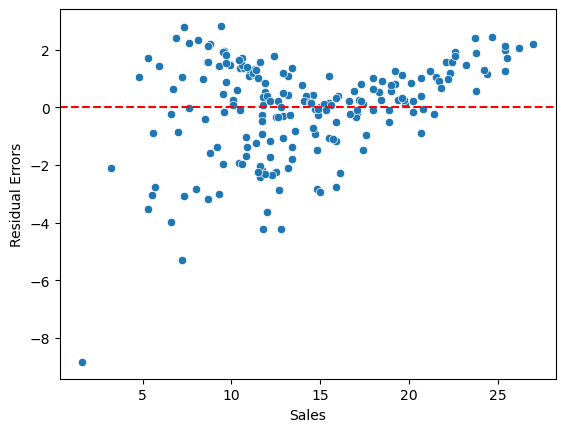

In [6]:
from sklearn.linear_model import LinearRegression
df = pd.read_csv("datasets/advertising4D.csv")
X = df.drop('sales', axis=1)
y = np.array(df['sales'])
model = LinearRegression()
model.fit(X, y)

yhat = model.predict(X)
residual_errors = y - yhat
sns.scatterplot(x=y, y=residual_errors)
plt.axhline(y=0, color='r', ls='--')

plt.xlabel('Sales')
plt.ylabel("Residual Errors")

<font face = "Garamond" color=green size=5>**d. Normality:**
- <font face = "Garamond" color=red size=4>What do you mean by this assumption?</font><br>
    - The residuals (errors) of the regression line are approximately normally distributed. 
- <font face = "Garamond" color=red size=4>How to determine if this assumption is met?</font><br>
    - This can be checked by drawing the histogram of the residuals. If it is not skewed, that means the assumption is satisfied. OR, you can use Q-Q plot, short for quantile-quantile plot. If the points on the plot roughly form a straight diagonal line, then the normality assumption is met.
- <font face = "Garamond" color=red size=4>Problem Caused?</font><br>
    - Incorrect Regression coefficients.
- <font face = "Garamond" color=red size=4>What to do if this assumption is violated?</font><br>
    - First, verify that any outliers aren’t having a huge impact on the distribution. If there are outliers present, make sure that they are real values and that they aren’t data entry errors.
    - Next, you can apply a nonlinear transformation to the independent and/or dependent variable. Common examples include taking the log, the square root, or the reciprocal of the independent and/or dependent variable.


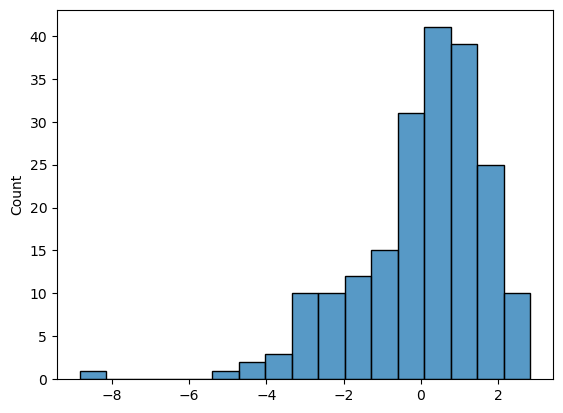

In [7]:
sns.histplot(data=residual_errors);

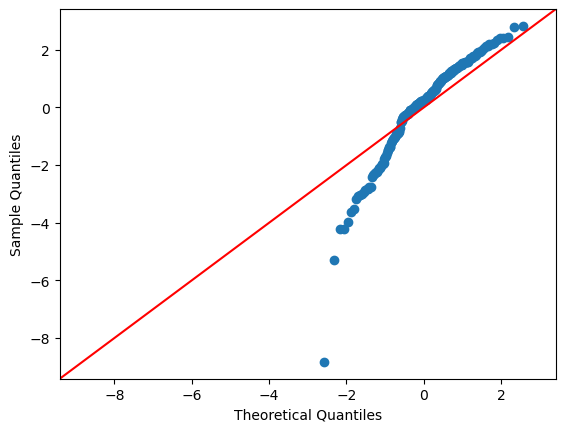

In [8]:
# qqplot is the graphical plotting of the quantiles of two distributions with respect to each other.
# qqplot lets you compare how close two distributions are, and is used to assess normality in linear regression.
import statsmodels.api as sm
import pylab as py
  
sm.qqplot(residual_errors, line ='45')
py.show()

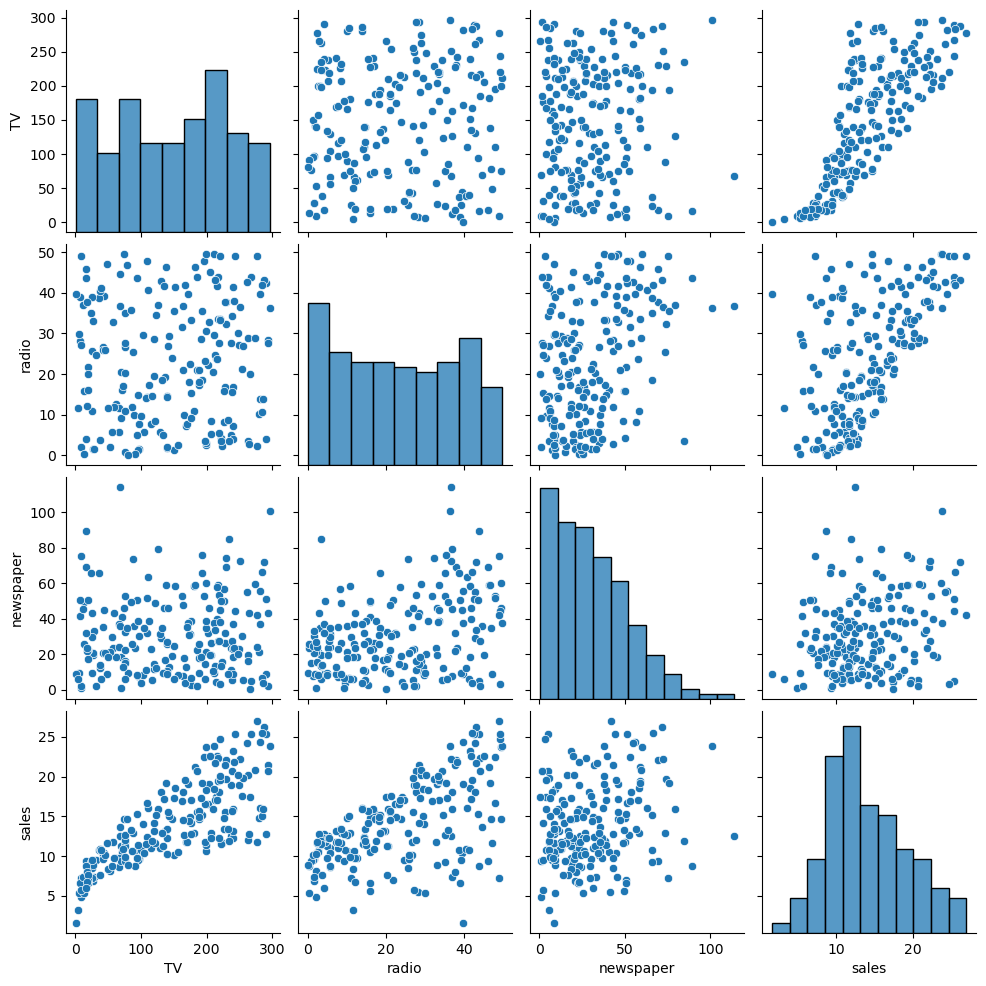

In [9]:
sns.pairplot(df);

## IV. Train-Test-Split

## a. A Bad Approach
<h3 align="center"><div class="alert alert-success" style="margin: 20px">A terrible approach is to use all of the available data to train the model and then test the model using the same data</h3>

<img align="center" width="800" src="images/cv1.png"  >

## b. Train-Test-Split Method
- Holdout cross validation method involves removing a certain portion of data and using it as test data.
- The machine learning model is trained on the training data and then asked to predict the output on the test data

<img align="center" width="800" src="images/cv2.png"  >

<img align="center" width="1000"  src="images/sup-ml2.png"  > 

## c. Applying Train-Test-Split Method on Advertising Dataset

<img align="center" width="1200" src="images/cv3.png"  >

<br><br>
<font face = "Garamond" color=red size=5>Later we will see Cross Validation, which is a process that simulates multiple Train-Test-Splits on the available dataset</font>

In [9]:
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [10]:
X = df.drop('sales', axis=1)    # df.iloc[:,0:2]
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [11]:
y = df['sales']     # df.iloc[:,-1]
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=54)

len(df), len(X_train), len(y_train), len(X_test), len(y_test)

(200, 160, 160, 40, 40)

In [19]:
X_train

,TV,radio,newspaper
7,120.2,19.6,11.6
191,75.5,10.8,6.0
59,210.7,29.5,9.3
34,95.7,1.4,7.4
175,276.9,48.9,41.8
...,...,...,...
23,228.3,16.9,26.2
15,195.4,47.7,52.9
130,0.7,39.6,8.7
69,216.8,43.9,27.2


In [20]:
y_train

7      13.2
191     9.9
59     18.4
34      9.5
175    27.0
       ... 
23     15.5
15     22.4
130     1.6
69     22.3
111    21.8
Name: sales, Length: 160, dtype: float64

In [21]:
X_test.head()

,TV,radio,newspaper
179,165.6,10.0,17.6
166,17.9,37.6,21.6
187,191.1,28.7,18.2
119,19.4,16.0,22.3
186,139.5,2.1,26.6


In [22]:
y_test.head()

179    12.6
166     8.0
187    17.3
119     6.6
186    10.3
Name: sales, dtype: float64

## V. Create Model/Estimator Instance

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">In sklearn, an estimator is a Python object that implements the <em>fit(X, y)</em> and <em>predict(X)</em> methods </h3>


<center><font face = "Courier New" color=green size=6>from &nbsp;&nbsp; sklearn.</font><font face = "Courier New" color=blue size=6>model_family</font> <font face = "Courier New" color=green size=6>&nbsp;&nbsp;  import </font><font face = "Courier New" color=magenta size=6>&nbsp;&nbsp; Estimator</font></center><br>

<font face = "Courier New" color=green size=2.9>from sklearn.</font><font face = "Courier New" color=blue size=3>linear_model</font> <font face = "Courier New" color=green size=3>&nbsp; import </font><font face = "Courier New" color=magenta size=3>LinearRegression,SGDRegressor,Lasso,Ridge,ElasticNet,LogisticRegression</font><br>

<font face = "Courier New" color=green size=3>from sklearn.</font><font face = "Courier New" color=blue size=3>neighbors</font> <font face = "Courier New" color=green size=3>&nbsp; import </font><font face = "Courier New" color=magenta size=3>KNeighborsRegressor, KNeighborsClassifier</font><br>

<font face = "Courier New" color=green size=3>from sklearn.</font><font face = "Courier New" color=blue size=3>svm</font> <font face = "Courier New" color=green size=3>&nbsp; &nbsp; &nbsp;&nbsp;&nbsp; import </font><font face = "Courier New" color=magenta size=3>LinearSVR, LinearSVC, SVR, SVC</font><br>

<font face = "Courier New" color=green size=3>from sklearn.</font><font face = "Courier New" color=blue size=3>naive_bayes</font> <font face = "Courier New" color=green size=3> import </font><font face = "Courier New" color=magenta size=3>BernoulliNB, MultinomialNB, CategoricalNB, GaussianNB</font><br>
  
<font face = "Courier New" color=green size=3>from sklearn.</font><font face = "Courier New" color=blue size=3>tree</font> <font face = "Courier New" color=green size=3>&nbsp; &nbsp; &nbsp;&nbsp; import </font><font face = "Courier New" color=magenta size=3>DecisionTreeRegressor, DecisionTreeClassifier</font><br>

<font face = "Courier New" color=green size=3>from sklearn.</font><font face = "Courier New" color=blue size=3>ensemble</font> <font face = "Courier New" color=green size=3>&nbsp;  import </font><font face = "Courier New" color=magenta size=3>RandomForestRegressor, RandomForestClassifier, AdaBoostRegressor, AdaBoostClassifier, GradientBoostingRegressor, GradientBoostingClassifier</font>

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
#help(LinearRegression)

In [25]:
lr_model = LinearRegression()

## VI Train the Model

In [26]:
lr_model.fit(X_train, y_train);

In [27]:
lr_model.coef_

array([ 0.04597903,  0.18579595, -0.0030992 ])

> **Interprete the Regression Coefficients:**
>- Since there are three input features in our data set, so there are three regression coefficients
>- 0.185 is the regression coefficient related to radio ad, and this value means that if you keep the other two features TV, and newspaper constant and make  change in radio ad amount only, then one unit increase in TV ad budget the sale will increase by 0.18 units

In [28]:
lr_model.intercept_

3.055121653762061

> **Interprete Intercept Value:**
>- The intercept value tells us that if we spend nothing on advertisement, i.e., keep all the input feature as zero the sales will be of 3.05 units

In [29]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


>- Synergy Effect or Interaction Effect is a phenomenon that arises in the multiple linear regression setting in machine learning, when increase in the value of one Independent variable increases the impact of another Independent variable on the dependent Variable.

## VII. Evaluate the Model
<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Evaluation allows us to check the accuracy of our trained model by testing it on data that has never been used for training </h3>

In [30]:
X_test.head()

,TV,radio,newspaper
179,165.6,10.0,17.6
166,17.9,37.6,21.6
187,191.1,28.7,18.2
119,19.4,16.0,22.3
186,139.5,2.1,26.6


In [31]:
y_test.head()

179    12.6
166     8.0
187    17.3
119     6.6
186    10.3
Name: sales, dtype: float64

In [32]:
y_predicted = lr_model.predict(X_test)
y_predicted

array([12.47266269, 10.79713122, 17.11765267,  6.85073786,  9.77692921,
       11.72016397, 19.24446371, 10.46662309, 15.44509966, 16.13139908,
        9.78080142, 14.04705019, 16.53392308, 17.37352548,  8.84995583,
       23.11499   ,  8.19088085, 13.19373337,  9.84007626, 11.3593746 ,
       18.77622105, 12.03294526, 18.98214139, 20.44351881, 14.0199199 ,
       13.49422896, 12.15922044, 24.04539408,  9.17661604, 14.72829612,
       20.02443673,  9.83109916, 19.37855769, 21.19271869, 18.1905889 ,
       20.82406301,  6.60613385, 15.29816677, 20.363702  ,  6.15630662])

In [33]:
test_residuals = y_test - y_predicted
test_residuals

179    0.127337
166   -2.797131
187    0.182347
119   -0.250738
186    0.523071
134   -0.920164
142    0.855536
12    -1.266623
118    0.454900
178   -4.331399
138   -0.180801
43    -1.147050
194    0.766077
11     0.026475
44    -0.349956
101    0.685010
49     1.509119
4     -0.293733
149    0.259924
31     0.540625
188   -2.876221
116    0.167055
33    -1.582141
0      1.656481
181   -1.819920
161   -0.194229
2     -2.859220
183    2.154606
125    1.423384
81    -2.428296
176    0.175563
145    0.468901
124    0.321442
55     2.507281
153    0.809411
137   -0.024063
182    2.093866
156    0.001833
104    0.336298
106    1.043693
Name: sales, dtype: float64

### Regression Metrics:
#### (i) Mean Absolute Error:
$$ \large MAE = \frac{1}{n}\sum_{i=1}^n|y_i - \hat{y}_i| \hspace{12cm}$$

#### (ii) Mean Squared Error:
$$\large MSE = \frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2\hspace{12.4cm}$$

#### (iii) Root Mean Squared Error:
$$ \large RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2}\hspace{11.5cm}$$

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [35]:
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)
print("MAE:", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)

MAE: 1.0602981028984602
MSE:  2.1533134134530854
RMSE:  1.4674172594913437


In [31]:
df['sales'].mean()

14.0225

In [41]:
1.46*100/14

10.428571428571429

In [53]:
1.23*100/20.5

6.0

>- Since the mean of the sales column is 14, so RMSE of 1.46 can be interpreted as roughly a 10% error.
>- **100$ Question:** Does a model having 10% error is good to be deployed?

### (iv) $R^2$ Score (Coefficient of Determination):

<img align="center" width="1000"  src="images/r2score.png"  >

$$ \large R^2 =  1 - \frac{SSE}{SST}$$


In [32]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_predicted)
print("R2 Score: ", r2)

R2 Score:  0.9175053931302267


> An R2 score of 0.917 means that 91.7% of the variance in the sales column of the advertising dataset is accounted for by the input features.

### (v) Adjusted $R^2$ Score:
- The limitation or R2 score is that, if you add more features to your model, the R2 score will either increase or stay the same, but will never decrease.
- Adjusted R2 score is a modified form of R2 score, whose value increases if new predictors tend to improve model's performance and decreases if new predictors do not improve performance as expected.

$$ \large R_a^2 =  \small 1 - \large [\frac{(1-R^2)(n-1)}{n-m-1}]\hspace{11.5cm}$$
- where,
    - `n` is number of observations
    - `m` is number of features/predictors/independent variables in model




In [33]:
n = len(X_test)
m = 3
r2_adj = 1 - ((1-r2)*(n-1)/(n-m-1))
print("R2 Adjusted: ", r2_adj)

R2 Adjusted:  0.9106308425577456


## VIII. Improve via Hyper-Parameter Tuning
    
    
|Ser | Hyperparameters | Model Parameters |
|:-:| :- | :- |
1 | Hyperparameters are set manually by ML engineer/practitioner prior to the start of the model’s training. | Model parameters are learnt by the learning algorithm during the training phase.|
2 | Hyperparameters are used to optimize machine learning model. |Model’s parameters are later used for prediction. |
3 | They are internal to the model. | Thy are external to the model. |Model’s parameters are later used for prediction. | 
4 | **Examples:** Learning rate and number of iterations in gradient descent or Neural Network,Value of K in KNN, number of trees in RandomForrest, Number of layers in a Neural Network, Number of perceptrons per layer in a Neural Network. |**Examples:**  Coefficients in a Linear or Logistic regression, support vectors in a support vector machine, and weights in an artificial neural network | 

## IX. Model Deployment and Monitoring
- Once you are happy with your training and hyperparameters, guided by the evaluation steps

<img align="center" width="900"  src="images/deployment.png"  > 

**Create and Train ML model:**

In [34]:
final_model = LinearRegression()
final_model.fit(np.array(X),y)

LinearRegression()

**Save the Trained Model on Disk:**

In [35]:
from joblib import dump
dump(final_model, 'adv_model.joblib')

['adv_model.joblib']

**Load the Trained Model from Disk:**

In [36]:
from joblib import load
loaded_model = load('adv_model.joblib')

**Give input to the model and predict:**

In [37]:
TV = 200
radio = 150
newspaper = 0
test_input = np.array([[TV, radio, newspaper]])
loaded_model.predict(test_input)

array([40.371321])

In [38]:
TV = 0
radio = 0
newspaper = 0
test_input = np.array([[TV, radio, newspaper]])
loaded_model.predict(test_input)

array([2.93888937])

>- The intercept value is 3.05, and it is comparable to about result :)

# 5. Task To Do
## (i) Apply LinearRegression Model
## (ii) Apply SGDRegressor Model

In [39]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)
df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930,220.0
